- A single Decision Tree gives Low Bias and High Variance But When multiple Decision Tree having Low_Bias and High_Variance connects together to form Low_Bias and Low_Variance, This is What we call Random Forest. Also Bias can be increased a little bit.

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

In [6]:
np.random.seed(42)
X,y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [7]:
X.shape

(500, 2)

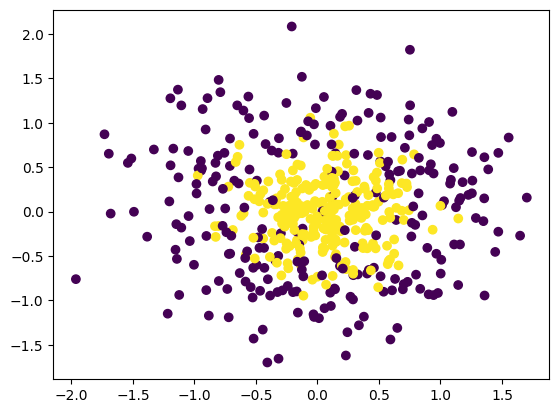

In [8]:
plt.scatter(X[:,0], X[:,1], c=y)

### Decision Tree

In [10]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

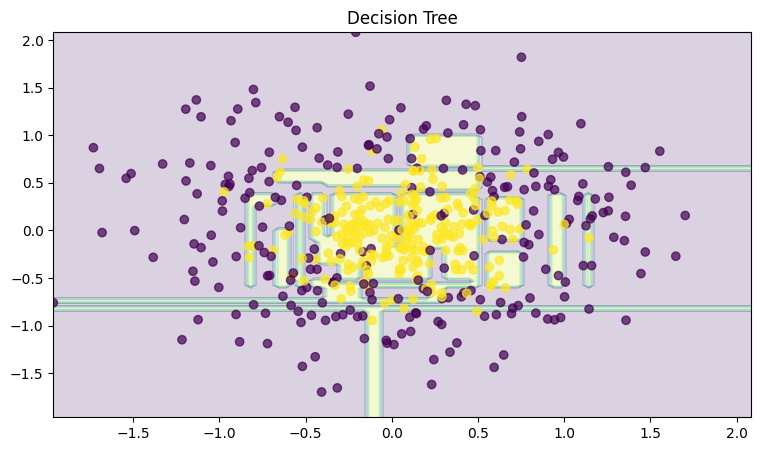

In [29]:
plt.figure(figsize=(9,5))
x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = dtree.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=0.7)
plt.title('Decision Tree')
plt.show()

### Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier
rf_tree = RandomForestClassifier(n_estimators=500,random_state=42)
rf_tree.fit(X_train, y_train)

RandomForestClassifier(n_estimators=500, random_state=42)

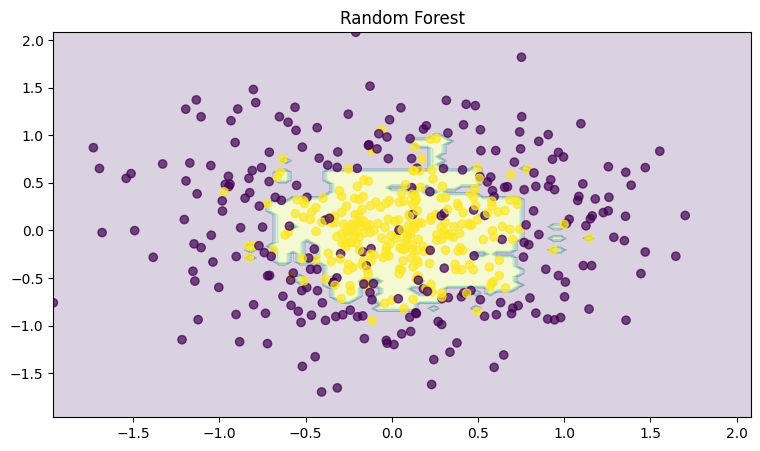

In [28]:
plt.figure(figsize=(9,5))
x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = rf_tree.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=0.7)
plt.title('Random Forest')
plt.show()

# Generate Random Data

In [30]:
n_train = 150
n_test = 1000
noise = 0.1

def f(x):
  x = x.ravel()
  return np.exp(-x**2) + 1.5 * np.exp(-(x-2)**2)

def generate(n_samples, noise):
  X = np.random.rand(n_samples) * 10 - 5
  X = np.sort(X).ravel()
  y = np.exp(-X**2) + 1.5 * np.exp(-(X-2)**2) + np.random.normal(0.0, noise, n_samples)
  X = X.reshape((n_samples, 1))
  return X,y

X_train, y_train = generate(n_samples=n_train, noise=noise)
X_test, y_test = generate(n_samples=n_test, noise=noise)

(-5.0, 5.0)

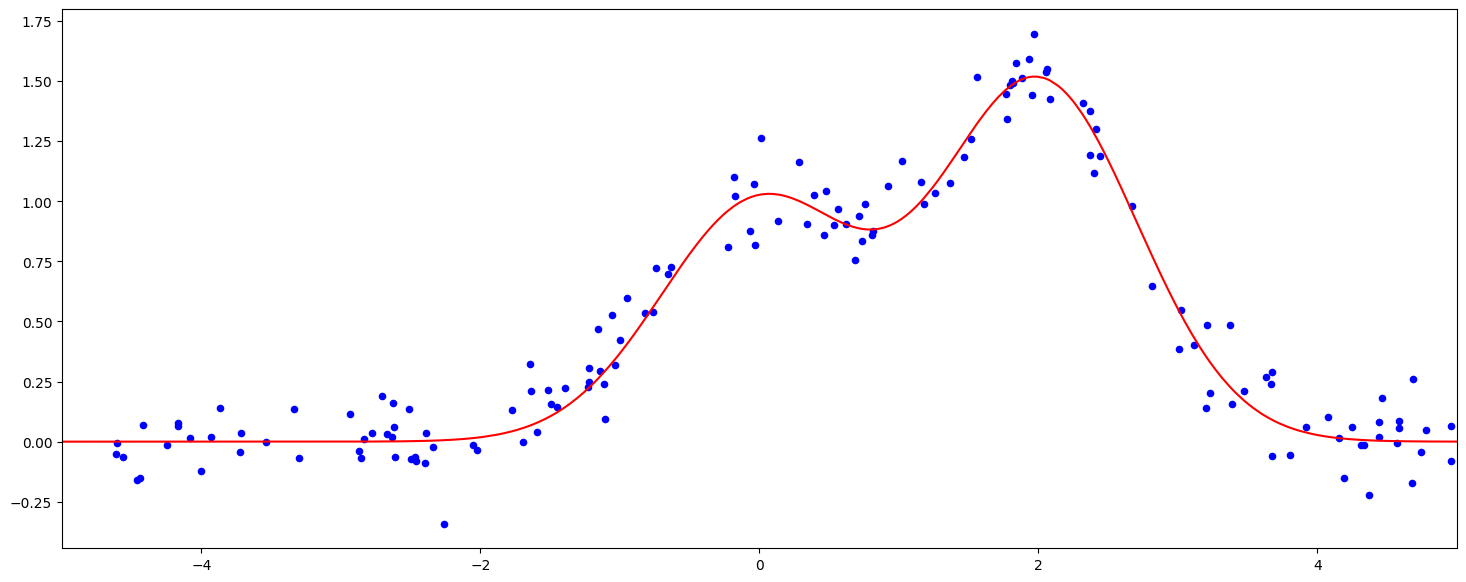

In [32]:
plt.figure(figsize=(18,7))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.xlim([-5,5])

# Single Decision Tree Regressor

Text(0.5, 1.0, 'Decision Tree, MSE = 22.70')

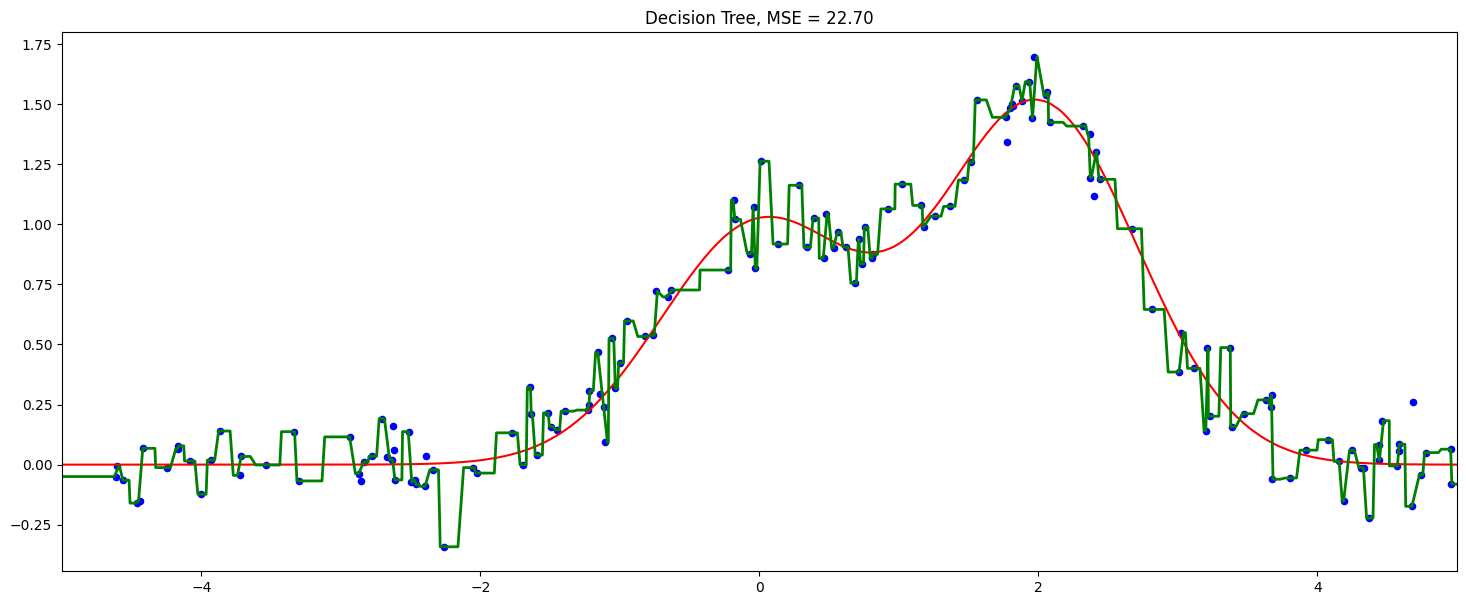

In [33]:
from sklearn.tree import DecisionTreeRegressor

dtree = DecisionTreeRegressor().fit(X_train, y_train)
d_predict = dtree.predict(X_test)

plt.figure(figsize=(18,7))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, d_predict, "g", lw=2)
plt.xlim([-5,5])
plt.title('Decision Tree, MSE = %.2f' % np.sum((y_test-d_predict)**2))

Text(0.5, 1.0, 'Random Forest, MSE = 15.73')

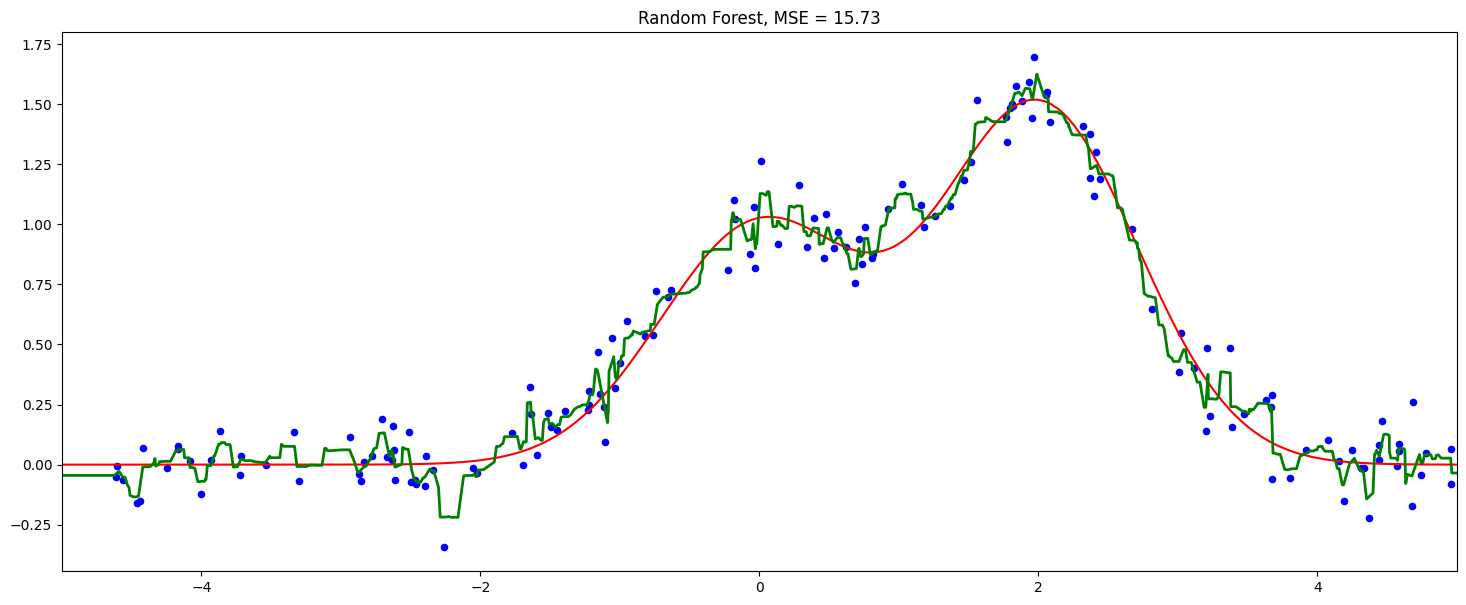

In [34]:
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators=1000).fit(X_train, y_train)
rf_predict = rfr.predict(X_test)

plt.figure(figsize=(18,7))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, rf_predict, "g", lw=2)
plt.xlim([-5,5])
plt.title('Random Forest, MSE = %.2f' % np.sum((y_test - rf_predict)**2))